Simulating with 1 channel(s), Correlation Matrix:
[[1.]]

===== M_MAX_WINDOWS = 20 =====

--- ORD Config: MSC_ch1_f0 (Base: MSC) ---
  H0 phase for MSC_ch1_f0...
    Threshold: 0.2112 (Emp. PFA_H0_primary: 0.0500)
    Emp. PFA_H0_secondary (on other noise freqs): 0.0090
    NDC=1: PFA_seq(H0)=0.8980, Avg_ATL_seq(H0)=4.08
    NDC=3: PFA_seq(H0)=0.3680, Avg_ATL_seq(H0)=14.77
  H1 phase for MSC_ch1_f0...
    SNR=-20.0dB: PD_single=0.015, PD_seq(NDC=1)=0.935, Avg_ATL(NDC=1)=3.42
    SNR=-10.0dB: PD_single=0.125, PD_seq(NDC=1)=0.930, Avg_ATL(NDC=1)=3.60
    SNR=0.0dB: PD_single=0.965, PD_seq(NDC=1)=1.000, Avg_ATL(NDC=1)=2.24

--- ORD Config: CSM_ch1_f0 (Base: CSM) ---
  H0 phase for CSM_ch1_f0...
    Threshold: 0.2100 (Emp. PFA_H0_primary: 0.0500)
    Emp. PFA_H0_secondary (on other noise freqs): 0.0123
    NDC=1: PFA_seq(H0)=1.0000, Avg_ATL_seq(H0)=1.00
    NDC=3: PFA_seq(H0)=0.3330, Avg_ATL_seq(H0)=15.23
  H1 phase for CSM_ch1_f0...
    SNR=-20.0dB: PD_single=0.010, PD_seq(NDC=1)=1.000, A

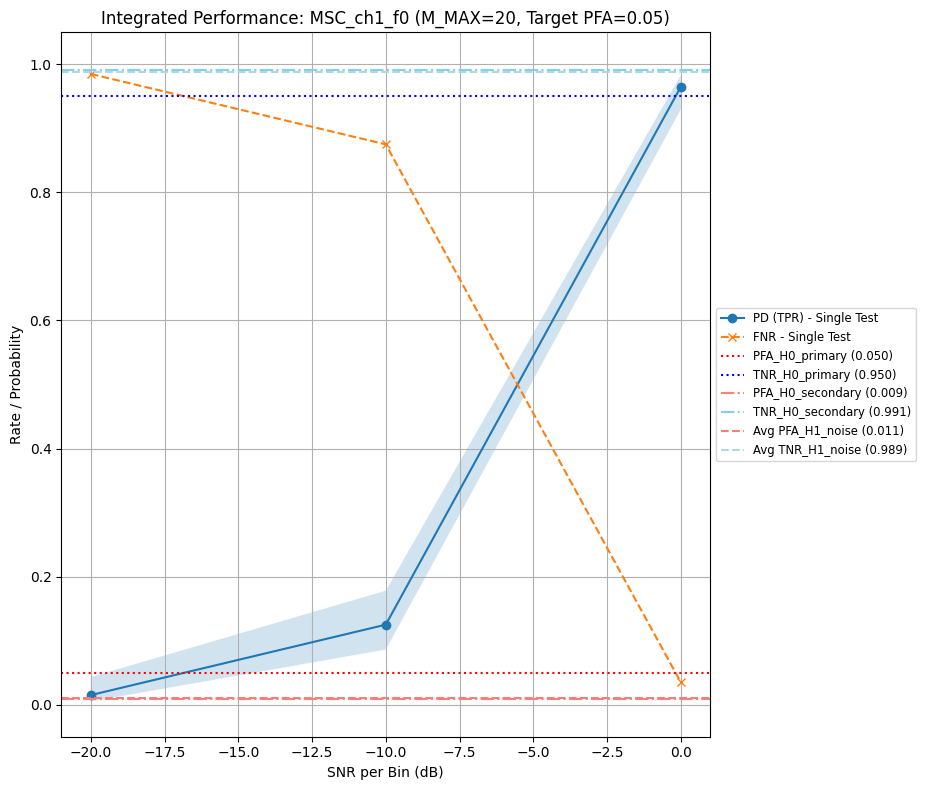

Comprehensive Simulation Framework - Stage with Enhanced Metrics and Plotting Foundation Complete.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, scoreatpercentile
import time
import pandas as pd
from collections import defaultdict
import pickle # For saving/loading complex results including distributions

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, scoreatpercentile # Used in wilson_score and thresholding
from collections import defaultdict # Used in the main sim loop
import pandas as pd # For results_df and plotting parts
import pickle # For saving/loading

# --- ORD Helper Functions ---
def msc_fft_py(Y_input_all_bins, M_win):
    """
    Calculates Magnitude Squared Coherence for all bins.
    Args:
        Y_input_all_bins (np.ndarray): Complex FFT coefficients (num_bins, M_win_actual).
        M_win (int): Number of windows/epochs intended (used for denominator scaling).
                     The actual number of windows used is Y_input_all_bins.shape[1].
    Returns:
        np.ndarray: MSC values for each bin (num_bins,).
    """
    if Y_input_all_bins.ndim == 1: # Single bin passed as (M_win,)
        Y_input_all_bins = Y_input_all_bins.reshape(1, -1)
        
    num_bins, M_win_actual = Y_input_all_bins.shape

    if M_win_actual == 0:
        return np.zeros(num_bins)
    if M_win_actual < 2: # MSC is typically 1 or undefined for M_win < 2
        return np.zeros(num_bins) # Or np.ones(num_bins) depending on definition for M=1

    # Numerator: |sum(X_i(f))|^2
    sum_Y_fft = np.sum(Y_input_all_bins, axis=1)
    numerator = np.abs(sum_Y_fft)**2

    # Denominator: M * sum(|X_i(f)|^2)
    sum_abs_Y_fft_sq = np.sum(np.abs(Y_input_all_bins)**2, axis=1)
    denominator = M_win_actual * sum_abs_Y_fft_sq # Use actual M_win for scaling

    msc = np.zeros(num_bins, dtype=float)
    valid_den_mask = denominator != 0
    msc[valid_den_mask] = numerator[valid_den_mask] / denominator[valid_den_mask]
    
    msc[np.isnan(msc)] = 0.0
    msc[np.isinf(msc)] = 0.0 # Or a large capped value, or based on max finite value
    return msc

def csm_fft_py(Y_fft_all_windows, M_win_dummy=None): # M_win_dummy not directly used
    """
    Calculates Component Synchrony Measure (Phase Coherence) for all bins.
    Args:
        Y_fft_all_windows (np.ndarray): Complex FFT coefficients (num_bins, M_win_actual).
    Returns:
        np.ndarray: CSM values for each bin (num_bins,).
    """
    if Y_fft_all_windows.ndim == 1: # Single bin passed as (M_win,)
        Y_fft_all_windows = Y_fft_all_windows.reshape(1, -1)

    num_bins, M_win_actual = Y_fft_all_windows.shape
    if M_win_actual == 0:
        return np.zeros(num_bins)

    phases = np.angle(Y_fft_all_windows)
    mean_cos = np.mean(np.cos(phases), axis=1)
    mean_sin = np.mean(np.sin(phases), axis=1)
    csm_spectrum = mean_cos**2 + mean_sin**2
    csm_spectrum[np.isnan(csm_spectrum)] = 0.0
    return csm_spectrum

def lft_fft_py(Y_fft_all_windows_single_chan, M_win_dummy, L_neighbors):
    """
    Calculates Local F-Test for a single channel's full spectrum.
    Args:
        Y_fft_all_windows_single_chan (np.ndarray): Complex FFT (num_bins, M_win_actual).
        L_neighbors (int): Number of neighboring bins on each side for noise estimation.
    Returns:
        np.ndarray: LFT values for each bin (num_bins,).
    """
    num_bins, M_win_actual = Y_fft_all_windows_single_chan.shape
    if M_win_actual == 0:
        return np.zeros(num_bins)
        
    power_spectrum_per_window = np.abs(Y_fft_all_windows_single_chan)**2
    avg_power_spectrum = np.mean(power_spectrum_per_window, axis=1)
    lft_spectrum = np.zeros(num_bins, dtype=float)

    for f_idx in range(num_bins):
        signal_power = avg_power_spectrum[f_idx]
        
        lower_indices = np.arange(max(0, f_idx - L_neighbors), f_idx)
        upper_indices = np.arange(f_idx + 1, min(num_bins, f_idx + L_neighbors + 1))
        all_neighbor_indices = np.unique(np.concatenate((lower_indices, upper_indices)).astype(int))
        # Ensure neighbors are valid and distinct from f_idx
        valid_neighbors = all_neighbor_indices[(all_neighbor_indices >= 0) & (all_neighbor_indices < num_bins) & (all_neighbor_indices != f_idx)]
        
        if len(valid_neighbors) < L_neighbors / 2 : # Heuristic: need at least some neighbors
             mean_noise_power = 1e-12 # Avoid division by zero
        else:
            noise_power_bins = avg_power_spectrum[valid_neighbors]
            mean_noise_power = np.mean(noise_power_bins) if len(noise_power_bins) > 0 else 1e-12

        if mean_noise_power < 1e-12: lft_spectrum[f_idx] = signal_power / 1e-12
        else: lft_spectrum[f_idx] = signal_power / mean_noise_power
            
    lft_spectrum[np.isnan(lft_spectrum)] = 0.0
    finite_max = np.max(lft_spectrum[~np.isinf(lft_spectrum)], initial=1e6) # Cap inf values based on finite max
    lft_spectrum[np.isinf(lft_spectrum)] = finite_max if finite_max > 0 else 1e6 # Ensure positive cap
    return lft_spectrum

def gft_fft_py(Y_fft_all_windows_single_chan, target_bin_index, M_win_actual, noise_bins_mask=None, NFFT_val=512):
    """
    Calculates Global F-Test for a single channel.
    Args:
        Y_fft_all_windows_single_chan (np.ndarray): Complex FFT (num_bins, M_win_actual).
        target_bin_index (int): Index of the signal bin.
        M_win_actual (int): Actual number of windows used. (Can also get from shape)
        noise_bins_mask (np.ndarray, optional): Boolean mask for noise bins.
        NFFT_val (int): FFT length, used if noise_bins_mask is None to exclude DC/Nyquist.
    Returns:
        float: GFT value.
    """
    num_bins, M_win_actual_data = Y_fft_all_windows_single_chan.shape
    if M_win_actual_data == 0: return np.nan
    
    power_spectrum_epochs = np.abs(Y_fft_all_windows_single_chan[:, :M_win_actual_data])**2
    avg_power_spectrum = np.mean(power_spectrum_epochs, axis=1) # (num_bins,)
    
    if not (0 <= target_bin_index < len(avg_power_spectrum)): return np.nan
    signal_power = avg_power_spectrum[target_bin_index]
    
    num_total_bins = len(avg_power_spectrum)
    if noise_bins_mask is None:
        noise_bins_mask = np.ones(num_total_bins, dtype=bool)
        noise_bins_mask[target_bin_index] = False
        if 0 < num_total_bins : noise_bins_mask[0] = False # Exclude DC
        if NFFT_val//2 < num_total_bins : noise_bins_mask[NFFT_val//2] = False # Exclude Nyquist if present
        
    noise_power_values = avg_power_spectrum[noise_bins_mask]
    
    if len(noise_power_values) == 0: return np.nan 
    
    mean_noise_power = np.mean(noise_power_values)
    
    if mean_noise_power < 1e-12:
        return signal_power / 1e-12 
    gft_val = signal_power / mean_noise_power
    return gft_val if not np.isnan(gft_val) else 0.0

def ht2_fft_py(Y_fft_epoch_data_single_bin_M_win, M_win_actual):
    """
    Calculates Hotelling's T^2 for a single frequency bin across epochs.
    Args:
        Y_fft_epoch_data_single_bin_M_win (np.ndarray): Complex FFT coefficients for ONE bin, shape (M_win_actual,).
        M_win_actual (int): Number of windows/epochs.
    Returns:
        float: Hotelling's T^2 statistic.
    """
    if M_win_actual < 2 : return np.nan # Need at least 2 epochs for covariance
        
    Y_complex = Y_fft_epoch_data_single_bin_M_win.flatten()
    if len(Y_complex) != M_win_actual: return np.nan

    data_2d = np.array([Y_complex.real, Y_complex.imag]).T # Shape (M_win_actual, 2)
    
    try:
        mean_vector = np.mean(data_2d, axis=0) # Shape (2,)
        if M_win_actual <= 2 : # Need M_win > p (p=2 dimensions) for non-singular cov matrix
            return 0.0 # Or np.nan. T2=0 if cov is singular and mean_vector is zero
        
        cov_matrix = np.cov(data_2d, rowvar=False, ddof=1) # ddof=1 for sample covariance
        
        # Check for singularity (e.g., if all Re or Im are same)
        if np.linalg.matrix_rank(cov_matrix) < 2:
             return 1e7 if np.any(np.abs(mean_vector) > 1e-9) else 0.0 # Large if signal likely, else 0

        inv_cov_matrix = np.linalg.inv(cov_matrix)
        t_squared = M_win_actual * (mean_vector.T @ inv_cov_matrix @ mean_vector)
        return t_squared if not np.isnan(t_squared) else 0.0
    except np.linalg.LinAlgError: 
        return 1e7 if np.any(np.abs(mean_vector) > 1e-9) else 0.0 # Fallback if inversion fails
    except Exception: 
        return np.nan

# --- Utility Functions ---
def generate_correlated_noise_mc(num_samples_total, num_channels, sigma_sq_time, correlation_matrix):
    if correlation_matrix.shape[0] != num_channels or correlation_matrix.shape[1] != num_channels:
        raise ValueError("Correlation matrix dimensions must match num_channels.")
    std_dev = np.sqrt(sigma_sq_time)
    D = np.diag(np.full(num_channels, std_dev))
    covariance_matrix = D @ correlation_matrix @ D
    
    independent_noise = np.random.randn(num_channels, num_samples_total)
    try:
        L = np.linalg.cholesky(covariance_matrix)
        correlated_noise_transposed = L @ independent_noise
        return correlated_noise_transposed.T 
    except np.linalg.LinAlgError:
        # print("Warning: Cholesky decomposition failed for noise generation. Using independent noise.")
        return np.sqrt(sigma_sq_time) * np.random.randn(num_samples_total, num_channels)

def wilson_score_interval_py(k, n, confidence_level=0.95):
    if n == 0 or np.isnan(n) or np.isnan(k) or k < 0 or n < k : return np.nan, (np.nan, np.nan)
    k = float(np.nan_to_num(k)); n = float(n) # Ensure float for division
    alpha = 1 - confidence_level; z = norm.ppf(1 - alpha / 2)
    phat = k / n
    
    term1_num = phat + (z**2) / (2 * n)
    term2_sqrt_arg = (phat * (1 - phat) / n) + (z**2) / (4 * n**2)
    if term2_sqrt_arg < 0: term2_sqrt_arg = 0 # Handle potential small negative due to precision
    term2_num = z * np.sqrt(term2_sqrt_arg)
    denominator = 1 + (z**2) / n
    
    pci_l = max(0.0, (term1_num - term2_num) / denominator)
    pci_u = min(1.0, (term1_num + term2_num) / denominator)
    return phat, (pci_l, pci_u)

def adjust_freqs_get_bins_py(nominal_freqs, NFFT_val, FS_rate):
    adj_freqs = np.zeros_like(nominal_freqs, dtype=float)
    bin_indices = np.zeros_like(nominal_freqs, dtype=int)
    for i, f_val in enumerate(nominal_freqs):
        bin_idx_ideal = int(round(f_val * NFFT_val / FS_rate))
        adj_freqs[i] = bin_idx_ideal * FS_rate / NFFT_val
        bin_indices[i] = bin_idx_ideal 
    return adj_freqs, bin_indices

# --- Enhanced ORD Calculation ---
def get_ord_value_enhanced(Y_fft_trial_data_all_channels, # (num_channels_sim, num_freq_bins, current_m_windows)
                           current_m_windows,
                           ord_config, 
                           target_fundamental_bin_index, 
                           FS_rate, NFFT_val):
    if current_m_windows == 0: return np.nan
    
    base_ord_name = ord_config['base_ord']
    num_sim_channels = Y_fft_trial_data_all_channels.shape[0]
    # num_ord_channels determines how many of the simulated channels are used for this ORD config
    num_ord_channels = ord_config.get('num_channels_for_ord', num_sim_channels) 
    
    # Ensure we don't try to use more channels than available
    num_ord_channels = min(num_ord_channels, num_sim_channels)

    Y_data_for_ord_calc = Y_fft_trial_data_all_channels[:num_ord_channels, :, :current_m_windows]

    ord_values_per_channel_after_q = []

    for chan_idx in range(num_ord_channels):
        Y_chan_data = Y_data_for_ord_calc[chan_idx, :, :] # (num_freq_bins, current_m_windows)
        
        harmonic_bins_to_eval = [target_fundamental_bin_index]
        if ord_config.get('q_num_harmonics', 0) > 0:
            fundamental_freq_hz = target_fundamental_bin_index * FS_rate / NFFT_val
            for h_num in range(1, ord_config['q_num_harmonics'] + 1):
                harmonic_freq_ideal = fundamental_freq_hz * (h_num + 1) # f0, 2*f0, 3*f0 ...
                harmonic_bin = int(round(harmonic_freq_ideal * NFFT_val / FS_rate))
                if 0 <= harmonic_bin <= NFFT_val // 2 and harmonic_bin not in harmonic_bins_to_eval:
                    harmonic_bins_to_eval.append(harmonic_bin)
        harmonic_bins_to_eval = sorted(list(set(harmonic_bins_to_eval)))

        ord_stats_for_harmonics_this_channel = []
        for bin_idx_eval in harmonic_bins_to_eval:
            if not (0 <= bin_idx_eval < Y_chan_data.shape[0]): # Check bin_idx_eval is valid
                ord_stats_for_harmonics_this_channel.append(np.nan)
                continue

            ord_stat_one_bin = np.nan
            # Y_chan_data_single_bin has shape (current_m_windows,) for HT2
            # Y_chan_data_single_bin_reshaped has shape (1, current_m_windows) for MSC, CSM
            Y_chan_data_single_bin_reshaped = Y_chan_data[bin_idx_eval, :].reshape(1, current_m_windows)
            
            if base_ord_name == 'MSC':
                ord_stat_one_bin = msc_fft_py(Y_chan_data_single_bin_reshaped, current_m_windows)[0]
            elif base_ord_name == 'CSM':
                ord_stat_one_bin = csm_fft_py(Y_chan_data_single_bin_reshaped, current_m_windows)[0]
            elif base_ord_name == 'HT2':
                ord_stat_one_bin = ht2_fft_py(Y_chan_data[bin_idx_eval, :], current_m_windows)
            elif base_ord_name == 'LFT':
                lft_spectrum_this_chan = lft_fft_py(Y_chan_data, current_m_windows, ord_config.get('L_lft', 2))
                if bin_idx_eval < len(lft_spectrum_this_chan): ord_stat_one_bin = lft_spectrum_this_chan[bin_idx_eval]
            elif base_ord_name == 'GFT':
                ord_stat_one_bin = gft_fft_py(Y_chan_data, bin_idx_eval, current_m_windows, NFFT_val=NFFT_val)
            
            if not np.isnan(ord_stat_one_bin):
                ord_stats_for_harmonics_this_channel.append(ord_stat_one_bin)
        
        if not ord_stats_for_harmonics_this_channel:
            ord_values_per_channel_after_q.append(np.nan)
            continue

        q_combined_stat_this_channel = np.nan
        if ord_config.get('q_num_harmonics', 0) == 0 or len(ord_stats_for_harmonics_this_channel) == 1:
            q_combined_stat_this_channel = ord_stats_for_harmonics_this_channel[0]
        else:
            q_method = ord_config.get('q_combination', 'sum')
            if q_method == 'sum': q_combined_stat_this_channel = np.nansum(ord_stats_for_harmonics_this_channel)
            elif q_method == 'average': q_combined_stat_this_channel = np.nanmean(ord_stats_for_harmonics_this_channel)
            elif q_method == 'product': q_combined_stat_this_channel = np.nanprod([max(s, 1e-9) for s in ord_stats_for_harmonics_this_channel if not np.isnan(s)]) # product of non-NaNs
            elif q_method == 'max': q_combined_stat_this_channel = np.nanmax(ord_stats_for_harmonics_this_channel)
        ord_values_per_channel_after_q.append(q_combined_stat_this_channel)

    valid_ord_values_post_q = [s for s in ord_values_per_channel_after_q if not np.isnan(s)]
    if not valid_ord_values_post_q: return np.nan

    final_ord_value = np.nan
    # If single channel ORD or no channel combination specified, or only one channel's data is valid post-q
    if num_ord_channels == 1 or not ord_config.get('channel_combination') or len(valid_ord_values_post_q) == 1:
        final_ord_value = valid_ord_values_post_q[0]
    else: # Multi-channel combination
        chan_combo_method = ord_config['channel_combination']
        if chan_combo_method == 'average': final_ord_value = np.mean(valid_ord_values_post_q)
        elif chan_combo_method == 'product': # Geometric mean
            # Ensure positive values for product/geometric mean if values can be zero or negative
            # Using max(s, 1e-9) for stability, assuming ORDs are generally non-negative.
            prods = [max(s, 1e-9) for s in valid_ord_values_post_q]
            final_ord_value = np.prod(prods) ** (1.0 / len(prods)) if prods else np.nan
        elif chan_combo_method == 'max': final_ord_value = np.max(valid_ord_values_post_q)
            
    return final_ord_value

# --- Sequential Test Logic (Enhanced) ---
def run_sequential_test_enhanced(Y_fft_trial_data_all_channels, ord_config_dict, threshold, 
                                 target_fundamental_bin, M_MIN, M_MAX, NDC, FS_rate, NFFT_val_seq):
    consecutive_detections = 0
    # Adjust M_MIN based on ORD type if necessary (e.g., MSC needs at least 2 epochs)
    actual_m_min = M_MIN
    if ord_config_dict['base_ord'] == 'MSC' and actual_m_min < 2:
        actual_m_min = 2
    if ord_config_dict['base_ord'] == 'HT2' and actual_m_min < 2: # HT2 also needs M_win >= 2
        actual_m_min = 2
    
    actual_m_min = max(actual_m_min, 1) # Ensure M_MIN is at least 1

    for m_current in range(1, M_MAX + 1):
        if m_current < actual_m_min: # Don't make decision before actual_M_MIN
            # If NDC logic depends on prior states, you might still need to calculate ORD here
            # but for simple NDC counter, can skip ORD calculation.
            # Let's assume for now, for simple NDC, we reset if no decision can be made.
            if m_current < NDC : # If true M_MIN is less than NDC, reset counter until m_current >= NDC
                 consecutive_detections = 0
            continue # Skip decision if below M_MIN
        
        ord_val = get_ord_value_enhanced(Y_fft_trial_data_all_channels, m_current, ord_config_dict, 
                                         target_fundamental_bin, FS_rate, NFFT_val_seq)
        
        if not np.isnan(ord_val) and ord_val > threshold:
            consecutive_detections += 1
        else:
            consecutive_detections = 0 # Reset if below threshold or NaN
        
        if consecutive_detections >= NDC:
            return True, m_current # Detected
            
    return False, M_MAX # Not detected within M_MAX windows


# --- Plotting Function for "Integrated Performance Plot" ---
def plot_integrated_performance(df, ord_id_to_plot, m_max_to_plot, target_pfa_val, NDC_OPTIONS_PLOT):
    
    # Filter for H0 overall summary (single test) for this ORD_ID and M_MAX
    h0_summary_df_single = df[(df['ORD_ID'] == ord_id_to_plot) & 
                              (df['M_MAX'] == m_max_to_plot) & 
                              (df['SNR_dB'] == 'H0_Overall') &
                              (df['Test_Type'] == 'Single')]
    
    pfa_h0_pri_single = np.nan
    tnr_h0_pri_single = np.nan
    pfa_h0_sec_single = np.nan
    tnr_h0_sec_single = np.nan

    if not h0_summary_df_single.empty:
        pfa_h0_pri_single = h0_summary_df_single['PFA_H0_primary'].iloc[0]
        tnr_h0_pri_single = 1.0 - pfa_h0_pri_single if not np.isnan(pfa_h0_pri_single) else np.nan
        pfa_h0_sec_single = h0_summary_df_single['PFA_H0_secondary'].iloc[0]
        tnr_h0_sec_single = 1.0 - pfa_h0_sec_single if not np.isnan(pfa_h0_sec_single) else np.nan
    else:
        print(f"Warning: No H0_Overall (Single) summary for {ord_id_to_plot} at M_MAX {m_max_to_plot}. PFA lines might be from target or seq.")
        # Try to get H0_Overall_Seq for a default NDC if single H0 not present for lines
        h0_summary_df_seq_fallback = df[(df['ORD_ID'] == ord_id_to_plot) & 
                                        (df['M_MAX'] == m_max_to_plot) & 
                                        (df['SNR_dB'] == 'H0_Overall_Seq') & 
                                        (df['NDC'] == NDC_OPTIONS_PLOT[0] if NDC_OPTIONS_PLOT else 1)]
        if not h0_summary_df_seq_fallback.empty:
            pfa_h0_pri_single = h0_summary_df_seq_fallback['PFA_H0_primary'].iloc[0] # Use seq PFA as proxy
            tnr_h0_pri_single = 1.0 - pfa_h0_pri_single if not np.isnan(pfa_h0_pri_single) else np.nan
        else: # Absolute fallback
            pfa_h0_pri_single = target_pfa_val
            tnr_h0_pri_single = 1.0 - target_pfa_val


    h1_plot_df_single = df[(df['ORD_ID'] == ord_id_to_plot) & 
                           (df['M_MAX'] == m_max_to_plot) & 
                           (pd.to_numeric(df['SNR_dB'], errors='coerce').notna()) & # Ensure SNR_dB is numeric for H1
                           (df['Test_Type'] == 'Single')].copy()
    if not h1_plot_df_single.empty:
        h1_plot_df_single['SNR_dB_num'] = pd.to_numeric(h1_plot_df_single['SNR_dB'])
        h1_plot_df_single = h1_plot_df_single.sort_values(by='SNR_dB_num')
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    if not h1_plot_df_single.empty:
        ax.plot(h1_plot_df_single['SNR_dB_num'], h1_plot_df_single['PD_TPR'], marker='o', linestyle='-', label=f'PD (TPR) - Single ({ord_id_to_plot})')
        if 'PD_CI_low' in h1_plot_df_single.columns and 'PD_CI_high' in h1_plot_df_single.columns:
             ax.fill_between(h1_plot_df_single['SNR_dB_num'], h1_plot_df_single['PD_CI_low'], h1_plot_df_single['PD_CI_high'], alpha=0.2)
        ax.plot(h1_plot_df_single['SNR_dB_num'], h1_plot_df_single['FNR'], marker='x', linestyle='--', label=f'FNR - Single ({ord_id_to_plot})')
    else:
        print(f"No H1 data for Single Test for {ord_id_to_plot} at M_MAX={m_max_to_plot}")

    # Plot PFA/TNR lines from H0_Overall (Single test)
    ax.axhline(pfa_h0_pri_single, color='red', linestyle=':', label=f'PFA_H0_primary ({pfa_h0_pri_single:.3f})')
    if not np.isnan(tnr_h0_pri_single): ax.axhline(tnr_h0_pri_single, color='blue', linestyle=':', label=f'TNR_H0_primary ({tnr_h0_pri_single:.3f})')
    if not np.isnan(pfa_h0_sec_single): ax.axhline(pfa_h0_sec_single, color='salmon', linestyle='-.', label=f'PFA_H0_secondary ({pfa_h0_sec_single:.3f})')
    if not np.isnan(tnr_h0_sec_single): ax.axhline(tnr_h0_sec_single, color='skyblue', linestyle='-.', label=f'TNR_H0_secondary ({tnr_h0_sec_single:.3f})')

    if not h1_plot_df_single.empty:
        avg_pfa_h1_noise = h1_plot_df_single['PFA_H1_noise'].mean()
        avg_tnr_h1_noise = h1_plot_df_single['TNR_H1_noise'].mean()
        if not np.isnan(avg_pfa_h1_noise): ax.axhline(avg_pfa_h1_noise, color='lightcoral', linestyle='--', label=f'Avg PFA_H1_noise ({avg_pfa_h1_noise:.3f})')
        if not np.isnan(avg_tnr_h1_noise): ax.axhline(avg_tnr_h1_noise, color='lightblue', linestyle='--', label=f'Avg TNR_H1_noise ({avg_tnr_h1_noise:.3f})')

    ax.set_title(f'Integrated Performance: {ord_id_to_plot} (M_MAX={m_max_to_plot}, Target PFA={target_pfa_val:.2f})')
    ax.set_xlabel('SNR per Bin (dB)'); ax.set_ylabel('Rate / Probability')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small'); ax.grid(True); ax.set_ylim([-0.05, 1.05])
    plt.tight_layout(rect=[0,0,0.78,1])
    plt.show()

# --- Plotting PD vs ATL for Sequential ---
def plot_pd_vs_atl_sequential(df, ord_id_to_plot, m_max_to_plot, snr_levels_plot, ndc_options_plot):
    fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"Sequential Performance: {ord_id_to_plot}, M_MAX={m_max_to_plot} (Target PFA ~ {target_pfa})", fontsize=14)

    # PD Plot
    ax1 = axs[0]
    # Single test H1 data for this ORD and M_MAX
    single_h1_df = df[(df['ORD_ID'] == ord_id_to_plot) &
                      (df['M_MAX'] == m_max_to_plot) &
                      (pd.to_numeric(df['SNR_dB'], errors='coerce').notna()) &
                      (df['Test_Type'] == 'Single')].copy()
    if not single_h1_df.empty:
        single_h1_df['SNR_dB_num'] = pd.to_numeric(single_h1_df['SNR_dB'])
        single_h1_df = single_h1_df.sort_values(by='SNR_dB_num')
        ax1.plot(single_h1_df['SNR_dB_num'], single_h1_df['PD_TPR'], marker='x', linestyle='--', label='PD Single Test', color='black')

    for ndc_val in ndc_options_plot:
        seq_h1_df_ndc = df[(df['ORD_ID'] == ord_id_to_plot) &
                           (df['M_MAX'] == m_max_to_plot) &
                           (pd.to_numeric(df['SNR_dB'], errors='coerce').notna()) &
                           (df['Test_Type'] == 'Sequential') & (df['NDC'] == ndc_val)].copy()
        if not seq_h1_df_ndc.empty:
            seq_h1_df_ndc['SNR_dB_num'] = pd.to_numeric(seq_h1_df_ndc['SNR_dB'])
            seq_h1_df_ndc = seq_h1_df_ndc.sort_values(by='SNR_dB_num')
            ax1.plot(seq_h1_df_ndc['SNR_dB_num'], seq_h1_df_ndc['PD_TPR'], marker='o', label=f'PD Seq (NDC={ndc_val})')
    
    ax1.set_ylabel('Probability of Detection (PD/TPR)')
    ax1.set_title('Detection Performance (PD vs SNR)')
    ax1.legend(loc='lower right', fontsize='small'); ax1.grid(True); ax1.set_ylim([-0.05, 1.05])

    # ATL Plot
    ax2 = axs[1]
    if not single_h1_df.empty:
         ax2.plot(single_h1_df['SNR_dB_num'], single_h1_df['ATL_ANW'], marker='x', linestyle='--', label='ATL Single Test', color='black')

    for ndc_val in ndc_options_plot:
        seq_h1_df_ndc = df[(df['ORD_ID'] == ord_id_to_plot) &
                           (df['M_MAX'] == m_max_to_plot) &
                           (pd.to_numeric(df['SNR_dB'], errors='coerce').notna()) &
                           (df['Test_Type'] == 'Sequential') & (df['NDC'] == ndc_val)].copy()
        if not seq_h1_df_ndc.empty:
            seq_h1_df_ndc['SNR_dB_num'] = pd.to_numeric(seq_h1_df_ndc['SNR_dB'])
            seq_h1_df_ndc = seq_h1_df_ndc.sort_values(by='SNR_dB_num')
            ax2.plot(seq_h1_df_ndc['SNR_dB_num'], seq_h1_df_ndc['ATL_ANW'], marker='o', label=f'ATL Seq (NDC={ndc_val})')
    
    ax2.set_xlabel('SNR per Bin (dB)')
    ax2.set_ylabel('Average Test Length (Windows)')
    ax2.set_title('Test Efficiency (ATL vs SNR)')
    ax2.legend(loc='upper right', fontsize='small'); ax2.grid(True);
    ax2.set_ylim([0, m_max_to_plot + M_MAX_WINDOWS_OPTIONS[0]*0.1]) # Dynamic upper Ylim based on M_MAX
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# --- Simulation Parameters ---
FS = 1000; NFFT = 512;
L_neighbors_lft = 2 

NUM_CHANNELS_SIM = 1 # Start with 1 for faster initial full run, then test with 2
CHANNEL_CORRELATION = 0.0 # Use 0 for independent, 0.5 for correlated if NUM_CHANNELS_SIM > 1
if NUM_CHANNELS_SIM == 1:
    correlation_matrix_sim = np.array([[1.0]])
elif NUM_CHANNELS_SIM >= 2:
    # Simple Toeplitz-like correlation for >2 channels for now
    base_corr = np.array([CHANNEL_CORRELATION**i for i in range(NUM_CHANNELS_SIM)])
    correlation_matrix_sim = np.array([np.roll(base_corr, i) for i in range(NUM_CHANNELS_SIM)])
    # Symmetrize and ensure diagonal is 1
    correlation_matrix_sim = (correlation_matrix_sim + correlation_matrix_sim.T) / 2
    np.fill_diagonal(correlation_matrix_sim, 1.0)
    # Basic check for positive semi-definiteness (Cholesky will also check)
    if np.any(np.linalg.eigvals(correlation_matrix_sim) < -1e-9) and CHANNEL_CORRELATION != 0: # Allow for numerical noise if corr=0
        print(f"Warning: Generated correlation matrix for {NUM_CHANNELS_SIM} channels might not be PSD.")
        # Fallback or more robust generation needed for complex scenarios
        correlation_matrix_sim = np.eye(NUM_CHANNELS_SIM)


print(f"Simulating with {NUM_CHANNELS_SIM} channel(s), Correlation Matrix:\n{correlation_matrix_sim}")

signal_frequencies_nominal = np.array([82]) 
fp_reference_frequencies_nominal = np.array([41, 51, 61, 71]) # For H0 thresholding
noise_only_frequencies_H0_secondary = np.array([101, 111, 121, 131]) # For secondary PFA validation under H0
noise_only_frequencies_H1_evaluation = np.array([30, 50, 70, 120]) # Noise bins to check during H1 trials

target_pfa = 0.05
N_trials_H0 = 1000 # Increase to 5000-10000 for publication
N_trials_H1 = 200  # Increase to 500-1000 for publication

M_MAX_WINDOWS_OPTIONS = [20] 
snr_db_per_bin_range = np.arange(-20, 0 + 1, 10) 
NDC_OPTIONS = [1, 3] 

hanning_win = np.hanning(NFFT)
sigma_n_sq_time = 1.0
P_n_bin_expected = (2.0 / NFFT) * sigma_n_sq_time

# --- ORD Configurations (as defined previously, ensure IDs are unique) ---
ord_configurations_to_run = [
    {'id': 'MSC_ch1_f0', 'base_ord': 'MSC', 'num_channels_for_ord': 1, 'q_num_harmonics': 0},
    {'id': 'CSM_ch1_f0', 'base_ord': 'CSM', 'num_channels_for_ord': 1, 'q_num_harmonics': 0},
    {'id': 'LFT_ch1_f0', 'base_ord': 'LFT', 'num_channels_for_ord': 1, 'q_num_harmonics': 0, 'L_lft': L_neighbors_lft},
    {'id': 'HT2_ch1_f0', 'base_ord': 'HT2', 'num_channels_for_ord': 1, 'q_num_harmonics': 0},
    {'id': 'GFT_ch1_f0', 'base_ord': 'GFT', 'num_channels_for_ord': 1, 'q_num_harmonics': 0},
    {'id': 'qSumMSC_ch1_h1', 'base_ord': 'MSC', 'num_channels_for_ord': 1, 'q_num_harmonics': 1, 'q_combination': 'sum'},
]
if NUM_CHANNELS_SIM >= 2:
    ord_configurations_to_run.extend([
        {'id': 'aMSC_2ch_f0', 'base_ord': 'MSC', 'num_channels_for_ord': 2, 'channel_combination': 'average', 'q_num_harmonics': 0},
    ])

# --- Main Simulation ---
all_results_list = []
# Adjust frequencies and get global bin indices
signal_frequencies_adj, signal_bin_indices_py = adjust_freqs_get_bins_py(signal_frequencies_nominal, NFFT, FS)
fp_reference_frequencies_adj, fp_ref_bin_indices_py = adjust_freqs_get_bins_py(fp_reference_frequencies_nominal, NFFT, FS)
noise_only_H0_sec_adj, noise_only_H0_sec_bins = adjust_freqs_get_bins_py(noise_only_frequencies_H0_secondary, NFFT, FS)
noise_only_H1_eval_adj, noise_only_H1_eval_bins = adjust_freqs_get_bins_py(noise_only_frequencies_H1_evaluation, NFFT, FS)

target_signal_bin_fundamental = signal_bin_indices_py[0] if len(signal_bin_indices_py) > 0 else -1
if target_signal_bin_fundamental == -1: raise ValueError("No signal frequency defined!")

start_total_sim_time = time.time()

for M_MAX_CURRENT in M_MAX_WINDOWS_OPTIONS:
    print(f"\n===== M_MAX_WINDOWS = {M_MAX_CURRENT} =====")
    
    for ord_config in ord_configurations_to_run:
        current_ord_id = ord_config['id']
        print(f"\n--- ORD Config: {current_ord_id} (Base: {ord_config['base_ord']}) ---")

        # --- H0 Phase ---
        print(f"  H0 phase for {current_ord_id}...")
        # Store ORD values for each trial at each fp_reference_bin (fundamental)
        h0_ord_values_at_fp_ref_dist = [] # For ROC later: list of lists/arrays
        # Store the MAX ORD value (across fp_ref_bins) for each H0 trial (for thresholding)
        h0_max_ord_across_fp_ref_trials = np.full(N_trials_H0, np.nan)
        # Store ORD values at H0_secondary noise bins
        h0_ord_values_at_noise_secondary_dist = [] # list of lists/arrays

        for i_h0 in range(N_trials_H0):
            noise_mc_h0 = generate_correlated_noise_mc(NFFT * M_MAX_CURRENT, NUM_CHANNELS_SIM, sigma_n_sq_time, correlation_matrix_sim)
            Y_fft_H0_trial_all_ch = np.zeros((NUM_CHANNELS_SIM, NFFT // 2 + 1, M_MAX_CURRENT), dtype=complex)
            for ch_idx in range(NUM_CHANNELS_SIM):
                for k_win in range(M_MAX_CURRENT):
                    start = k_win * NFFT; end = (k_win + 1) * NFFT
                    Y_fft_H0_trial_all_ch[ch_idx, :, k_win] = np.fft.rfft(noise_mc_h0[start:end, ch_idx] * hanning_win)
            
            trial_ords_at_fp_ref = []
            for fp_fund_bin in fp_ref_bin_indices_py:
                ord_val = get_ord_value_enhanced(Y_fft_H0_trial_all_ch, M_MAX_CURRENT, ord_config, fp_fund_bin, FS, NFFT)
                if not np.isnan(ord_val): trial_ords_at_fp_ref.append(ord_val)
            if trial_ords_at_fp_ref:
                h0_ord_values_at_fp_ref_dist.append(trial_ords_at_fp_ref) # Store all for this trial
                h0_max_ord_across_fp_ref_trials[i_h0] = np.max(trial_ords_at_fp_ref)
            
            trial_ords_at_noise_secondary = []
            for ns_bin in noise_only_H0_sec_bins:
                ord_val_ns = get_ord_value_enhanced(Y_fft_H0_trial_all_ch, M_MAX_CURRENT, ord_config, ns_bin, FS, NFFT)
                if not np.isnan(ord_val_ns): trial_ords_at_noise_secondary.append(ord_val_ns)
            if trial_ords_at_noise_secondary: h0_ord_values_at_noise_secondary_dist.append(trial_ords_at_noise_secondary)

        valid_max_ord_H0 = h0_max_ord_across_fp_ref_trials[~np.isnan(h0_max_ord_across_fp_ref_trials)]
        if len(valid_max_ord_H0) < N_trials_H0 * 0.1: # Need a reasonable number of valid trials
            print(f"    Warning: Insufficient valid H0 trials for threshold for {current_ord_id} (found {len(valid_max_ord_H0)}). Skipping.")
            continue
        ord_threshold_current_config = scoreatpercentile(valid_max_ord_H0, (1 - target_pfa) * 100)
        
        # PFA_H0_primary (on fp_reference_bins, used for thresholding)
        pfa_h0_primary_val, pfa_h0_primary_ci = wilson_score_interval_py(np.sum(valid_max_ord_H0 > ord_threshold_current_config), len(valid_max_ord_H0))
        tnr_h0_primary_val = 1.0 - pfa_h0_primary_val if not np.isnan(pfa_h0_primary_val) else np.nan
        print(f"    Threshold: {ord_threshold_current_config:.4f} (Emp. PFA_H0_primary: {pfa_h0_primary_val:.4f})")

        # PFA_H0_secondary (on separate noise_only_frequencies_H0_secondary)
        h0_secondary_detections = 0
        h0_secondary_total_evals = 0
        flat_h0_ord_values_secondary = []
        for trial_vals in h0_ord_values_at_noise_secondary_dist:
            for val in trial_vals: flat_h0_ord_values_secondary.append(val) # For ROC
            h0_secondary_detections += np.sum(np.array(trial_vals) > ord_threshold_current_config)
            h0_secondary_total_evals += len(trial_vals)
        pfa_h0_secondary_val, pfa_h0_secondary_ci = wilson_score_interval_py(h0_secondary_detections, h0_secondary_total_evals)
        tnr_h0_secondary_val = 1.0 - pfa_h0_secondary_val if not np.isnan(pfa_h0_secondary_val) else np.nan
        print(f"    Emp. PFA_H0_secondary (on other noise freqs): {pfa_h0_secondary_val:.4f}")

        # Store H0 stats for single test (sequential H0 PFA comes later for each NDC)
        result_H0_single = {
            'ORD_ID': current_ord_id, 'M_MAX': M_MAX_CURRENT, 'SNR_dB': 'H0_Overall', 'NDC': 'Single', 
            'Test_Type': 'Single', 'Threshold': ord_threshold_current_config,
            'PFA_H0_primary': pfa_h0_primary_val, 'PFA_H0_primary_CI_low':pfa_h0_primary_ci[0], 'PFA_H0_primary_CI_high':pfa_h0_primary_ci[1],
            'TNR_H0_primary': tnr_h0_primary_val,
            'PFA_H0_secondary': pfa_h0_secondary_val, 'PFA_H0_secondary_CI_low':pfa_h0_secondary_ci[0], 'PFA_H0_secondary_CI_high':pfa_h0_secondary_ci[1],
            'TNR_H0_secondary': tnr_h0_secondary_val,
            'H0_fp_ref_dist': [v for sublist in h0_ord_values_at_fp_ref_dist for v in sublist], # Flattened list
            'H0_noise_secondary_dist': flat_h0_ord_values_secondary
        }
        # PD/FNR/PFA_H1/TNR_H1 are NaN for this H0 summary record
        for k_nan in ['PD_TPR', 'FNR', 'PFA_H1_noise', 'TNR_H1_noise', 'ATL_ANW']: result_H0_single[k_nan] = np.nan
        all_results_list.append(result_H0_single)
        
        # --- H0 for Sequential Tests ---
        # We need to run sequential test logic on H0 data using the determined threshold
        h0_seq_pfa_results = defaultdict(lambda: {'detections': 0, 'atl_list': []})
        for i_h0_seq in range(N_trials_H0): # This implies re-generating or re-using H0 FFT data
            # Re-generate H0 trial data for sequential test
            noise_mc_h0_seq = generate_correlated_noise_mc(NFFT * M_MAX_CURRENT, NUM_CHANNELS_SIM, sigma_n_sq_time, correlation_matrix_sim)
            Y_fft_H0_trial_all_ch_seq = np.zeros((NUM_CHANNELS_SIM, NFFT // 2 + 1, M_MAX_CURRENT), dtype=complex)
            for ch_idx in range(NUM_CHANNELS_SIM):
                for k_win in range(M_MAX_CURRENT):
                    start = k_win * NFFT; end = (k_win + 1) * NFFT
                    Y_fft_H0_trial_all_ch_seq[ch_idx, :, k_win] = np.fft.rfft(noise_mc_h0_seq[start:end, ch_idx] * hanning_win)

            # Simplified PFA_seq: test against one of the fp_reference_bins as target
            # A more rigorous approach would check if *any* fp_reference_bin leads to sequential detection
            target_h0_seq_fund_bin = fp_ref_bin_indices_py[0] 

            for ndc_val in NDC_OPTIONS:
                m_min_curr = max(1, ndc_val) 
                if ord_config['base_ord'] == 'MSC' and m_min_curr < 2: m_min_curr = 2 # MSC needs M>=2

                detected_seq, windows_used = run_sequential_test_enhanced(Y_fft_H0_trial_all_ch_seq, ord_config, 
                                                                          ord_threshold_current_config, target_h0_seq_fund_bin, 
                                                                          m_min_curr, M_MAX_CURRENT, ndc_val, FS, NFFT)
                if detected_seq: h0_seq_pfa_results[ndc_val]['detections'] += 1
                h0_seq_pfa_results[ndc_val]['atl_list'].append(windows_used)
        
        for ndc_val in NDC_OPTIONS:
            pfa_s_val, pfa_s_ci = wilson_score_interval_py(h0_seq_pfa_results[ndc_val]['detections'], N_trials_H0)
            atl_s_h0_val = np.mean(h0_seq_pfa_results[ndc_val]['atl_list']) if h0_seq_pfa_results[ndc_val]['atl_list'] else np.nan
            print(f"    NDC={ndc_val}: PFA_seq(H0)={pfa_s_val:.4f}, Avg_ATL_seq(H0)={atl_s_h0_val:.2f}")
            result_H0_seq_ndc = {
                'ORD_ID': current_ord_id, 'M_MAX': M_MAX_CURRENT, 'SNR_dB': 'H0_Overall_Seq', 'NDC': ndc_val,
                'Test_Type': 'Sequential', 'Threshold': ord_threshold_current_config,
                'PFA_H0_primary': pfa_s_val, 'PFA_H0_primary_CI_low':pfa_s_ci[0], 'PFA_H0_primary_CI_high':pfa_s_ci[1], # Using primary PFA field for seq H0 PFA
                'TNR_H0_primary': 1.0-pfa_s_val if not np.isnan(pfa_s_val) else np.nan,
                'ATL_ANW': atl_s_h0_val,
                # Other PFA/TNR/PD/FNR are NaN
            }
            for k_nan in ['PFA_H0_secondary','TNR_H0_secondary','PD_TPR', 'FNR', 'PFA_H1_noise', 'TNR_H1_noise']: result_H0_seq_ndc[k_nan] = np.nan
            all_results_list.append(result_H0_seq_ndc)


        # --- H1 Phase ---
        print(f"  H1 phase for {current_ord_id}...")
        for snr_db in snr_db_per_bin_range:
            current_snr_linear = 10**(snr_db / 10)
            P_s_bin_target = current_snr_linear * P_n_bin_expected
            A_signal = np.sqrt(2 * P_s_bin_target) if P_s_bin_target > 0 else 0

            h1_detections_single_count = 0
            h1_ord_values_at_signal_dist = []
            h1_ord_values_at_noise_eval_dist = []
            
            h1_seq_pd_results = defaultdict(lambda: {'detections': 0, 'atl_list': []})
            h1_seq_pfa_noise_bins_results = defaultdict(lambda: {'fp_detections':0, 'total_noise_bin_evals':0})


            for i_h1 in range(N_trials_H1):
                s_t_mc = np.zeros((NFFT * M_MAX_CURRENT, NUM_CHANNELS_SIM))
                if A_signal > 0 and target_signal_bin_fundamental != -1:
                    t_total = np.arange(NFFT * M_MAX_CURRENT) / FS
                    f0_hz = target_signal_bin_fundamental * FS / NFFT
                    base_signal_f0 = A_signal * np.sin(2 * np.pi * f0_hz * t_total)
                    for ch_idx in range(NUM_CHANNELS_SIM): s_t_mc[:, ch_idx] = base_signal_f0
                
                noise_mc_h1 = generate_correlated_noise_mc(NFFT * M_MAX_CURRENT, NUM_CHANNELS_SIM, sigma_n_sq_time, correlation_matrix_sim)
                x_t_mc_h1 = s_t_mc + noise_mc_h1
                
                Y_fft_H1_trial_all_ch = np.zeros((NUM_CHANNELS_SIM, NFFT // 2 + 1, M_MAX_CURRENT), dtype=complex)
                for ch_idx in range(NUM_CHANNELS_SIM):
                    for k_win in range(M_MAX_CURRENT):
                        start = k_win * NFFT; end = (k_win + 1) * NFFT
                        Y_fft_H1_trial_all_ch[ch_idx, :, k_win] = np.fft.rfft(x_t_mc_h1[start:end, ch_idx] * hanning_win)

                # Single Test H1 - PD
                ord_val_h1_single = get_ord_value_enhanced(Y_fft_H1_trial_all_ch, M_MAX_CURRENT, ord_config, 
                                                           target_signal_bin_fundamental, FS, NFFT)
                if not np.isnan(ord_val_h1_single):
                    h1_ord_values_at_signal_dist.append(ord_val_h1_single)
                    if ord_val_h1_single > ord_threshold_current_config:
                        h1_detections_single_count += 1
                
                # Single Test H1 - PFA on noise_only_frequencies_H1_evaluation
                trial_h1_noise_ords = []
                for h1_noise_bin in noise_only_H1_eval_bins:
                    ord_val_h1_noise = get_ord_value_enhanced(Y_fft_H1_trial_all_ch, M_MAX_CURRENT, ord_config,
                                                              h1_noise_bin, FS, NFFT) # Treat noise bin as fundamental for eval
                    if not np.isnan(ord_val_h1_noise): trial_h1_noise_ords.append(ord_val_h1_noise)
                if trial_h1_noise_ords: h1_ord_values_at_noise_eval_dist.extend(trial_h1_noise_ords) # Store all for ROC
                # For PFA_H1_noise, count if *any* of these noise bins exceed threshold (more rigorous)
                # Or average PFA per noise bin (simpler, as done before for H0_secondary)

                # Sequential Tests H1
                for ndc_val in NDC_OPTIONS:
                    m_min_curr = max(1, ndc_val)
                    if ord_config['base_ord'] == 'MSC' and m_min_curr < 2: m_min_curr = 2
                    
                    # PD Sequential
                    detected_seq, windows_used = run_sequential_test_enhanced(Y_fft_H1_trial_all_ch, ord_config, 
                                                                              ord_threshold_current_config, target_signal_bin_fundamental,
                                                                              m_min_curr, M_MAX_CURRENT, ndc_val, FS, NFFT)
                    if detected_seq: h1_seq_pd_results[ndc_val]['detections'] += 1
                    h1_seq_pd_results[ndc_val]['atl_list'].append(windows_used)

                    # PFA_H1_noise Sequential (simplified: evaluate one noise bin sequentially)
                    # More rigorous: check if *any* noise_only_H1_eval_bins detected sequentially
                    target_h1_noise_seq_bin = noise_only_H1_eval_bins[0] if len(noise_only_H1_eval_bins)>0 else -1
                    if target_h1_noise_seq_bin != -1:
                        detected_seq_noise, _ = run_sequential_test_enhanced(Y_fft_H1_trial_all_ch, ord_config,
                                                                          ord_threshold_current_config, target_h1_noise_seq_bin,
                                                                          m_min_curr, M_MAX_CURRENT, ndc_val, FS, NFFT)
                        if detected_seq_noise: h1_seq_pfa_noise_bins_results[ndc_val]['fp_detections'] += 1
                        h1_seq_pfa_noise_bins_results[ndc_val]['total_noise_bin_evals'] +=1 # Counts trials for this one noise bin

            # --- Store H1 Single Test Results for this SNR ---
            pd_single_val, pd_single_ci = wilson_score_interval_py(h1_detections_single_count, N_trials_H1)
            fnr_single_val = 1.0 - pd_single_val if not np.isnan(pd_single_val) else np.nan
            
            h1_noise_single_detections = np.sum(np.array(h1_ord_values_at_noise_eval_dist) > ord_threshold_current_config)
            pfa_h1_noise_single_val, pfa_h1_noise_single_ci = wilson_score_interval_py(h1_noise_single_detections, len(h1_ord_values_at_noise_eval_dist) if h1_ord_values_at_noise_eval_dist else 0)
            tnr_h1_noise_single_val = 1.0 - pfa_h1_noise_single_val if not np.isnan(pfa_h1_noise_single_val) else np.nan

            all_results_list.append({
                'ORD_ID': current_ord_id, 'M_MAX': M_MAX_CURRENT, 'SNR_dB': snr_db, 'NDC': 'Single', 
                'Test_Type': 'Single', 'Threshold': ord_threshold_current_config,
                'PD_TPR': pd_single_val, 'PD_CI_low':pd_single_ci[0],'PD_CI_high':pd_single_ci[1], 'FNR': fnr_single_val,
                'PFA_H1_noise': pfa_h1_noise_single_val, 'PFA_H1_noise_CI_low':pfa_h1_noise_single_ci[0],'PFA_H1_noise_CI_high':pfa_h1_noise_single_ci[1],
                'TNR_H1_noise': tnr_h1_noise_single_val,
                'ATL_ANW': M_MAX_CURRENT,
                'H1_signal_dist': list(h1_ord_values_at_signal_dist), # Store distribution
                'H1_noise_eval_dist': list(h1_ord_values_at_noise_eval_dist), # Store distribution
                # H0 PFA fields are NaN for H1 records
                'PFA_H0_primary':np.nan, 'TNR_H0_primary':np.nan,'PFA_H0_secondary':np.nan,'TNR_H0_secondary':np.nan
            })

            # --- Store H1 Sequential Test Results for this SNR ---
            for ndc_val in NDC_OPTIONS:
                pd_s_val, pd_s_ci = wilson_score_interval_py(h1_seq_pd_results[ndc_val]['detections'], N_trials_H1)
                fnr_s_val = 1.0 - pd_s_val if not np.isnan(pd_s_val) else np.nan
                atl_s_h1_val = np.mean(h1_seq_pd_results[ndc_val]['atl_list']) if h1_seq_pd_results[ndc_val]['atl_list'] else np.nan
                
                pfa_h1_noise_seq_val, pfa_h1_noise_seq_ci = wilson_score_interval_py(
                    h1_seq_pfa_noise_bins_results[ndc_val]['fp_detections'], 
                    h1_seq_pfa_noise_bins_results[ndc_val]['total_noise_bin_evals']
                )
                tnr_h1_noise_seq_val = 1.0 - pfa_h1_noise_seq_val if not np.isnan(pfa_h1_noise_seq_val) else np.nan

                all_results_list.append({
                    'ORD_ID': current_ord_id, 'M_MAX': M_MAX_CURRENT, 'SNR_dB': snr_db, 'NDC': ndc_val, 
                    'Test_Type': 'Sequential', 'Threshold': ord_threshold_current_config,
                    'PD_TPR': pd_s_val, 'PD_CI_low':pd_s_ci[0],'PD_CI_high':pd_s_ci[1], 'FNR': fnr_s_val,
                    'PFA_H1_noise': pfa_h1_noise_seq_val, 'PFA_H1_noise_CI_low':pfa_h1_noise_seq_ci[0],'PFA_H1_noise_CI_high':pfa_h1_noise_seq_ci[1],
                    'TNR_H1_noise': tnr_h1_noise_seq_val,
                    'ATL_ANW': atl_s_h1_val,
                    # H0 PFA fields and H1 dists are NaN for these summary seq records
                    'PFA_H0_primary':np.nan, 'TNR_H0_primary':np.nan,'PFA_H0_secondary':np.nan,'TNR_H0_secondary':np.nan,
                    'H1_signal_dist': [], 'H1_noise_eval_dist': [] 
                })
            print(f"    SNR={snr_db:.1f}dB: PD_single={pd_single_val:.3f}, PD_seq(NDC={NDC_OPTIONS[0]})={h1_seq_pd_results[NDC_OPTIONS[0]]['detections']/N_trials_H1 if N_trials_H1 > 0 else np.nan:.3f}, Avg_ATL(NDC={NDC_OPTIONS[0]})={np.mean(h1_seq_pd_results[NDC_OPTIONS[0]]['atl_list']) if h1_seq_pd_results[NDC_OPTIONS[0]]['atl_list'] else np.nan:.2f}")

# --- Save Full Results ---
results_df = pd.DataFrame(all_results_list)
print("\n--- Simulation Results DataFrame Head ---")
print(results_df.head())
results_filename = f"comprehensive_ord_sim_results_MMAX{M_MAX_WINDOWS_OPTIONS[0]}_NCh{NUM_CHANNELS_SIM}_Corr{CHANNEL_CORRELATION}.pkl"
with open(results_filename, 'wb') as f:
    pickle.dump(results_df, f)
print(f"Full results saved to {results_filename}")

end_total_sim_time = time.time()
print(f"\nTotal Simulation Time: {(end_total_sim_time - start_total_sim_time)/60:.2f} minutes")


# --- Plotting Function for "Integrated Performance Plot" ---
def plot_integrated_performance(df, ord_id_to_plot, m_max_to_plot, target_pfa_val):
    
    # Filter for H0 overall summary (single test) for this ORD_ID and M_MAX
    h0_summary_df = df[(df['ORD_ID'] == ord_id_to_plot) & 
                       (df['M_MAX'] == m_max_to_plot) & 
                       (df['SNR_dB'] == 'H0_Overall') &
                       (df['Test_Type'] == 'Single')]
    
    if h0_summary_df.empty:
        print(f"No H0_Overall summary data found for {ord_id_to_plot} at M_MAX {m_max_to_plot}")
        # Try to get H0_Overall_Seq for NDC=1 if single H0 not present
        h0_summary_df = df[(df['ORD_ID'] == ord_id_to_plot) & 
                           (df['M_MAX'] == m_max_to_plot) & 
                           (df['SNR_dB'] == 'H0_Overall_Seq') & # Fallback
                           (df['NDC'] == NDC_OPTIONS[0])] # Use first NDC for PFA lines
        if h0_summary_df.empty:
            print(f"No H0 summary data found at all for PFA lines for {ord_id_to_plot}. Cannot plot PFA lines.")
            pfa_h0_pri = target_pfa_val # Fallback to target
            pfa_h0_sec = target_pfa_val # Fallback to target
        else:
            pfa_h0_pri = h0_summary_df['PFA_H0_primary'].iloc[0]
            pfa_h0_sec = pfa_h0_pri # If secondary not specifically stored for seq H0 summary, use primary as proxy
    else:
        pfa_h0_pri = h0_summary_df['PFA_H0_primary'].iloc[0]
        pfa_h0_sec = h0_summary_df['PFA_H0_secondary'].iloc[0]

    tnr_h0_pri = 1.0 - pfa_h0_pri if not np.isnan(pfa_h0_pri) else np.nan
    tnr_h0_sec = 1.0 - pfa_h0_sec if not np.isnan(pfa_h0_sec) else np.nan

    # Data for PD/FN/PFA_H1 vs SNR (single test for this ORD_ID and M_MAX)
    h1_plot_df_single = df[(df['ORD_ID'] == ord_id_to_plot) & 
                           (df['M_MAX'] == m_max_to_plot) & 
                           (df['SNR_dB'] != 'H0_Overall') & (df['SNR_dB'] != 'H0_Overall_Seq') &
                           (df['Test_Type'] == 'Single')].copy()
    h1_plot_df_single['SNR_dB_num'] = pd.to_numeric(h1_plot_df_single['SNR_dB'])
    h1_plot_df_single = h1_plot_df_single.sort_values(by='SNR_dB_num')

    if h1_plot_df_single.empty:
        print(f"No H1 data to plot for {ord_id_to_plot} (Single Test).")
        return

    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot PD (TPR) and FNR
    ax.plot(h1_plot_df_single['SNR_dB_num'], h1_plot_df_single['PD_TPR'], marker='o', linestyle='-', label='PD (TPR) - Single Test')
    ax.fill_between(h1_plot_df_single['SNR_dB_num'], h1_plot_df_single['PD_CI_low'], h1_plot_df_single['PD_CI_high'], alpha=0.2)
    ax.plot(h1_plot_df_single['SNR_dB_num'], h1_plot_df_single['FNR'], marker='x', linestyle='--', label='FNR - Single Test')

    # Plot PFA/TNR lines
    ax.axhline(pfa_h0_pri, color='red', linestyle=':', label=f'PFA_H0_primary ({pfa_h0_pri:.3f})')
    ax.axhline(tnr_h0_pri, color='blue', linestyle=':', label=f'TNR_H0_primary ({tnr_h0_pri:.3f})')
    if not np.isnan(pfa_h0_sec):
        ax.axhline(pfa_h0_sec, color='salmon', linestyle='-.', label=f'PFA_H0_secondary ({pfa_h0_sec:.3f})')
    if not np.isnan(tnr_h0_sec) and not np.isnan(pfa_h0_sec): # only plot if pfa_h0_sec was valid
        ax.axhline(tnr_h0_sec, color='skyblue', linestyle='-.', label=f'TNR_H0_secondary ({tnr_h0_sec:.3f})')

    # Average PFA_H1_noise (as a function of SNR, if desired, or as an average horizontal line)
    # For now, let's plot the average PFA_H1_noise across SNRs if data exists
    avg_pfa_h1_noise = h1_plot_df_single['PFA_H1_noise'].mean()
    avg_tnr_h1_noise = h1_plot_df_single['TNR_H1_noise'].mean()
    if not np.isnan(avg_pfa_h1_noise):
        ax.axhline(avg_pfa_h1_noise, color='lightcoral', linestyle='--', label=f'Avg PFA_H1_noise ({avg_pfa_h1_noise:.3f})')
    if not np.isnan(avg_tnr_h1_noise):
        ax.axhline(avg_tnr_h1_noise, color='lightblue', linestyle='--', label=f'Avg TNR_H1_noise ({avg_tnr_h1_noise:.3f})')


    ax.set_title(f'Integrated Performance: {ord_id_to_plot} (M_MAX={m_max_to_plot}, Target PFA={target_pfa_val:.2f})')
    ax.set_xlabel('SNR per Bin (dB)'); ax.set_ylabel('Rate / Probability')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small'); ax.grid(True); ax.set_ylim([-0.05, 1.05])
    plt.tight_layout(rect=[0,0,0.78,1])
    plt.show()

# --- Example of calling the new plot function for the first ORD config and M_MAX ---
if not results_df.empty:
    first_ord_id = results_df['ORD_ID'].unique()[0]
    first_m_max = results_df['M_MAX'].unique()[0]
    plot_integrated_performance(results_df, first_ord_id, first_m_max, target_pfa)


print("Comprehensive Simulation Framework - Stage with Enhanced Metrics and Plotting Foundation Complete.")